# Compairing sequence and structure data

The following notebook compares the TCR:pMHC data from the collected sequences and structures to understand how representative these are of one another.

In [1]:
import logomaker
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from pyxdameraulevenshtein import damerau_levenshtein_distance

In [2]:
sequence_data = pd.read_csv('data/interim/sequences.csv')
sequence_data['type'] = 'sequence'

In [3]:
structure_data = pd.read_csv('data/processed/structures_summary.csv')
structure_data['type'] = 'structure'

Select only class I for structures

In [4]:
structure_data = structure_data.query("mhc_type == 'MH1'")

In [5]:
tcr_pmhc_data = pd.concat([sequence_data, structure_data])

In [6]:
tcr_pmhc_data.groupby('type').size()

type
sequence     13962
structure      216
dtype: int64

## Species

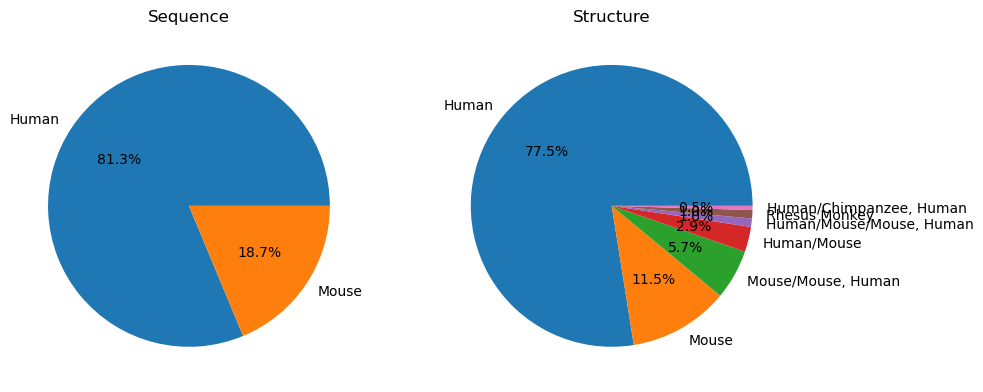

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 10))

species_proportions = tcr_pmhc_data.groupby('type')['species'].value_counts(normalize=True)

ax1.pie(species_proportions['sequence'], labels=species_proportions['sequence'].index, autopct='%1.1f%%')
ax1.set_title('Sequence')

ax2.pie(species_proportions['structure'], labels=species_proportions['structure'].index, autopct='%1.1f%%')
ax2.set_title('Structure')

plt.savefig('report/figures/dataset_comparison_species.svg')
plt.show()

## TCRs

### V-Gene usage

In [8]:
v_genes = tcr_pmhc_data[['v_alpha', 'v_beta', 'type']]

Removing entries with unknown genes

In [9]:
v_genes = v_genes.fillna('Unknown')

In [10]:
print('There are', len(v_genes[v_genes.eq('Unknown').any(axis=1)]), 'entries without gene information')

v_genes = v_genes[~v_genes.eq('Unknown').any(axis=1)]

There are 2 entries without gene information


Remove weird gene annotation

In [11]:
v_genes = v_genes[~v_genes['v_alpha'].str.startswith('TRB')]

In [12]:
for gene_group in 'v_alpha', 'v_beta':
    v_genes[f'{gene_group}_crop'] = (
        v_genes[gene_group]
        .str.split('-')
        .str[0]
        .str.split('*')
        .str[0]
        .replace('[A-Z]$', '', regex=True)
        .str.split(';')
        .str[0]
        .replace('TRAV|TRBV', '', regex=True)
    )

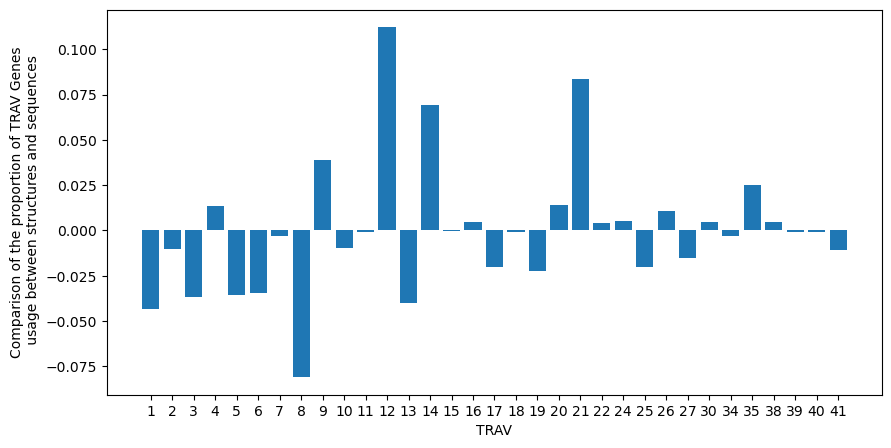

In [13]:
plt.figure(figsize=(10, 5))

v_alpha_comparison = (
    v_genes.groupby('type')['v_alpha_crop']
    .value_counts(normalize=True)
    .reset_index()
    .rename({'v_alpha_crop': 'TRAV'}, axis='columns')
    .pivot_table(index='TRAV', columns='type', values='proportion')
    .fillna(0.0)
)
v_alpha_comparison['gene_num'] = v_alpha_comparison.index.map(int)
v_alpha_comparison = v_alpha_comparison.sort_values('gene_num')


v_alpha_comparison['change'] = v_alpha_comparison['structure'] - v_alpha_comparison['sequence']

plt.bar(v_alpha_comparison.index, v_alpha_comparison['change'])

plt.ylabel('Comparison of the proportion of TRAV Genes\n usage between structures and sequences')
plt.xlabel('TRAV')

plt.savefig('report/figures/dataset_comparison_trav_genes.svg')
plt.show()

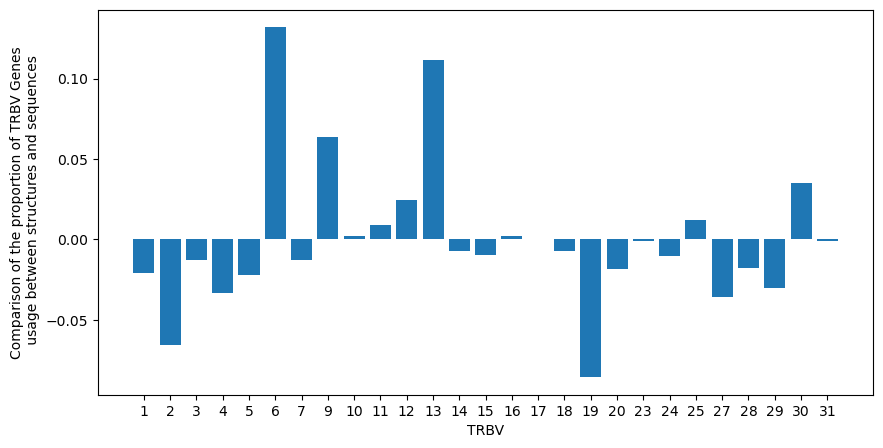

In [14]:
plt.figure(figsize=(10, 5))

v_beta_comparison = (
    v_genes.groupby('type')['v_beta_crop']
    .value_counts(normalize=True)
    .reset_index()
    .rename({'v_beta_crop': 'TRBV'}, axis='columns')
    .pivot_table(index='TRBV', columns='type', values='proportion')
    .fillna(0.0)
)
v_beta_comparison['gene_num'] = v_beta_comparison.index.map(int)
v_beta_comparison = v_beta_comparison.sort_values('gene_num')


v_beta_comparison['change'] = v_beta_comparison['structure'] - v_beta_comparison['sequence']

plt.bar(v_beta_comparison.index, v_beta_comparison['change'])

plt.ylabel('Comparison of the proportion of TRBV Genes\n usage between structures and sequences')
plt.xlabel('TRBV')

plt.savefig('report/figures/dataset_comparison_trbv_genes.svg')
plt.show()

In [15]:
v_gene_pairings = (
    v_genes.rename({'v_alpha_crop': 'TRAV', 'v_beta_crop': 'TRBV'}, axis='columns')
    .groupby('type')
    .value_counts(['TRAV', 'TRBV'], normalize=True)
    .reset_index()
)

In [16]:
travs = sorted(v_gene_pairings['TRAV'].unique())
trbvs = sorted(v_gene_pairings['TRBV'].unique())

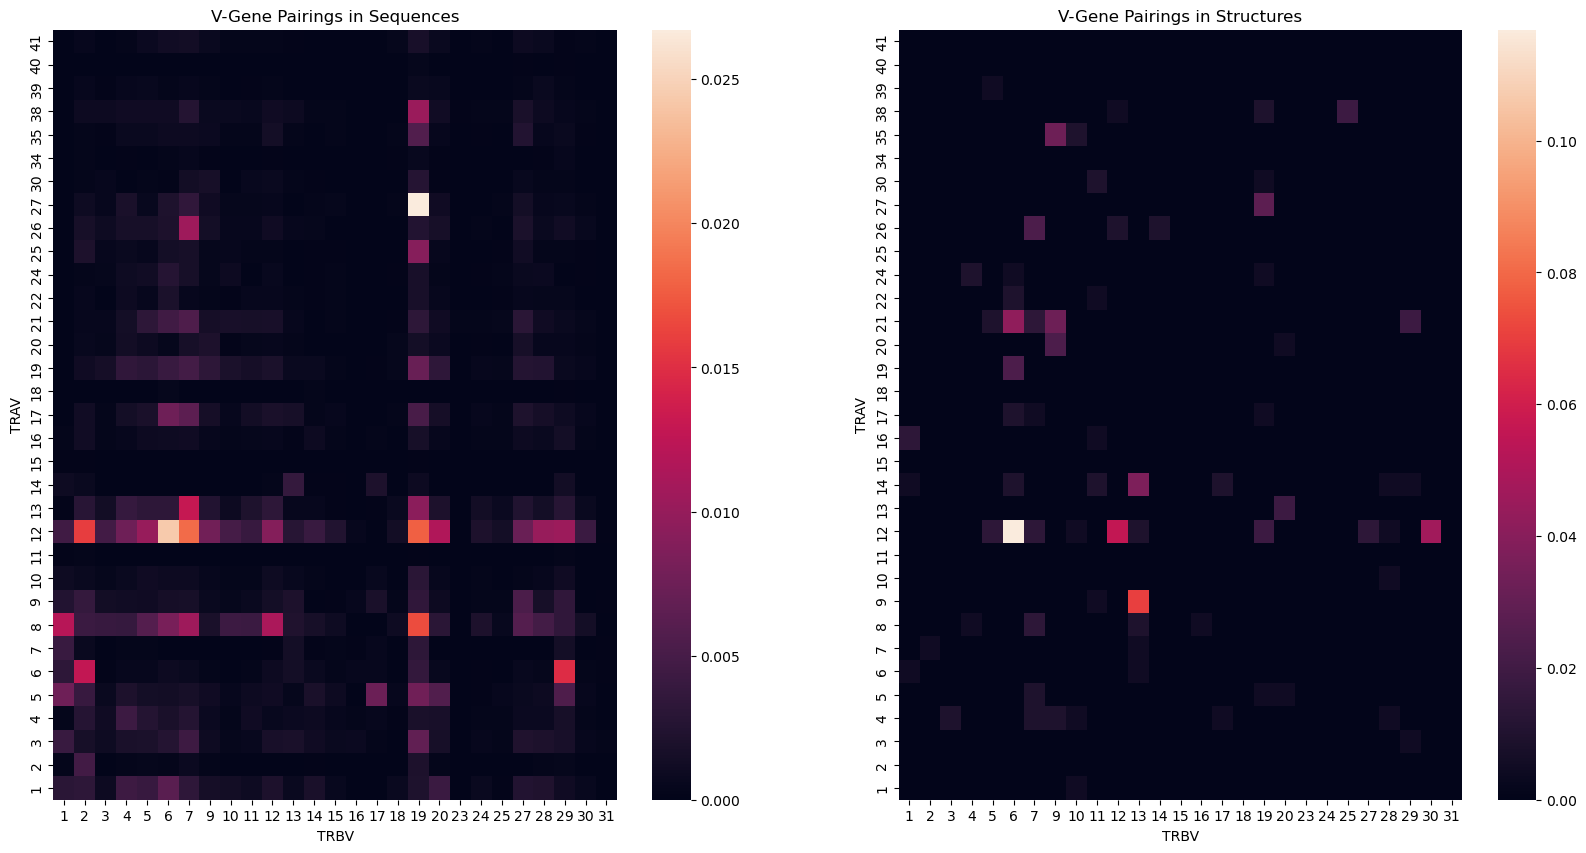

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

v_gene_pairings_sequence = v_gene_pairings.query("type == 'sequence'").pivot_table(
    index='TRAV', columns='TRBV', values='proportion'
)

v_gene_pairings_sequence[[label for label in trbvs if label not in v_gene_pairings_sequence.columns]] = np.nan
missing_table = pd.DataFrame(
    np.nan,
    index=pd.Series(
        [label for label in travs if label not in v_gene_pairings_sequence.index],
        name=v_gene_pairings_sequence.index.name,
    ),
    columns=v_gene_pairings_sequence.columns,
)
if not missing_table.empty:
    v_gene_pairings_sequence = pd.concat([v_gene_pairings_sequence, missing_table])


v_gene_pairings_sequence = v_gene_pairings_sequence[sorted(v_gene_pairings_sequence.columns, key=int)]
v_gene_pairings_sequence['key'] = v_gene_pairings_sequence.index.map(int)
v_gene_pairings_sequence = v_gene_pairings_sequence.sort_values('key', ascending=False)
v_gene_pairings_sequence = v_gene_pairings_sequence.drop('key', axis='columns')

sns.heatmap(v_gene_pairings_sequence.fillna(0), ax=ax1)

ax1.set_title('V-Gene Pairings in Sequences')

v_gene_pairings_structure = v_gene_pairings.query("type == 'structure'").pivot_table(
    index='TRAV', columns='TRBV', values='proportion'
)

v_gene_pairings_structure[[label for label in trbvs if label not in v_gene_pairings_structure.columns]] = np.nan
missing_table = pd.DataFrame(
    np.nan,
    index=pd.Series(
        [label for label in travs if label not in v_gene_pairings_structure.index],
        name=v_gene_pairings_structure.index.name,
    ),
    columns=v_gene_pairings_structure.columns,
)
if not missing_table.empty:
    v_gene_pairings_structure = pd.concat([v_gene_pairings_structure, missing_table])

v_gene_pairings_structure = v_gene_pairings_structure[sorted(v_gene_pairings_structure.columns, key=int)]
v_gene_pairings_structure['key'] = v_gene_pairings_structure.index.map(int)
v_gene_pairings_structure = v_gene_pairings_structure.sort_values('key', ascending=False)
v_gene_pairings_structure = v_gene_pairings_structure.drop('key', axis='columns')

sns.heatmap(v_gene_pairings_structure.fillna(0), ax=ax2)

ax2.set_title('V-Gene Pairings in Structures')

plt.show()

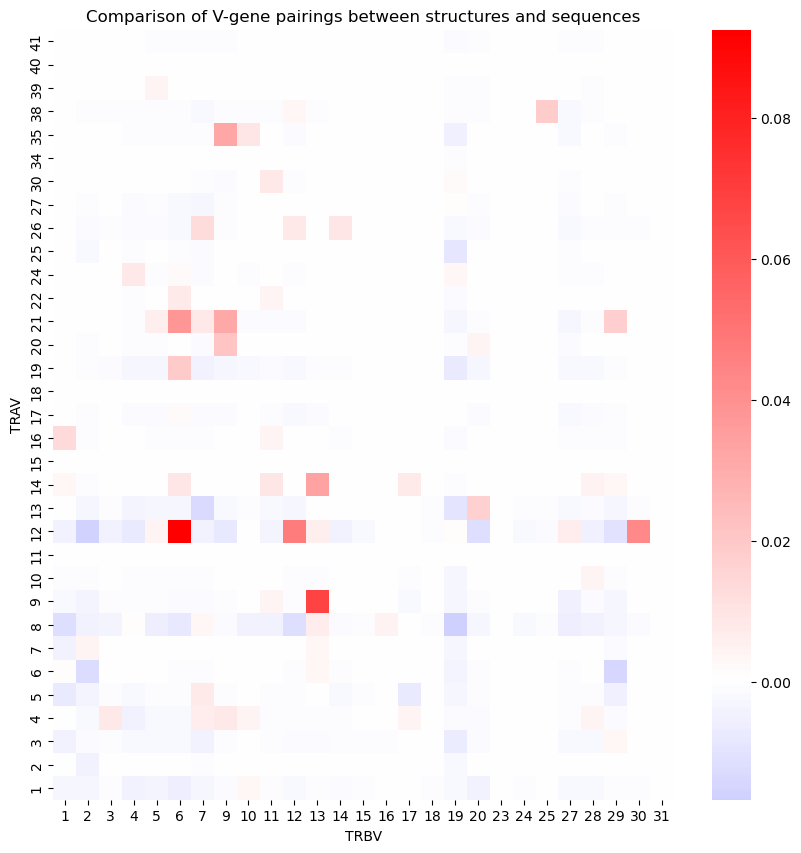

In [18]:
plt.figure(figsize=(10, 10))

cmap = LinearSegmentedColormap.from_list('french_flag', ['blue', 'white', 'red'], N=256)

sns.heatmap(v_gene_pairings_structure.fillna(0) - v_gene_pairings_sequence.fillna(0), cmap=cmap, center=0)
plt.title('Comparison of V-gene pairings between structures and sequences')

plt.show()

### CDR lengths

In [19]:
cdr_lengths = tcr_pmhc_data.filter(regex='cdr[1-3]_(alpha|beta)').map(len)
cdr_lengths['type'] = tcr_pmhc_data['type']

cdr_lengths = cdr_lengths.melt(
    id_vars=['type'],
    value_vars=[col for col in cdr_lengths.columns if col != 'type'],
    var_name='cdr_type',
    value_name='length',
)

cdr_lengths[['cdr_num', 'chain_type']] = cdr_lengths['cdr_type'].str.replace('cdr', '').str.split('_').apply(pd.Series)
cdr_lengths['cdr_num'] = cdr_lengths['cdr_num'].apply(int)

In [20]:
cdr_lengths_percentages = (
    cdr_lengths.groupby(['chain_type', 'cdr_num', 'type'])['length'].value_counts(normalize=True) * 100
)
cdr_lengths_percentages.name = 'percentage'
cdr_lengths_percentages = cdr_lengths_percentages.reset_index()

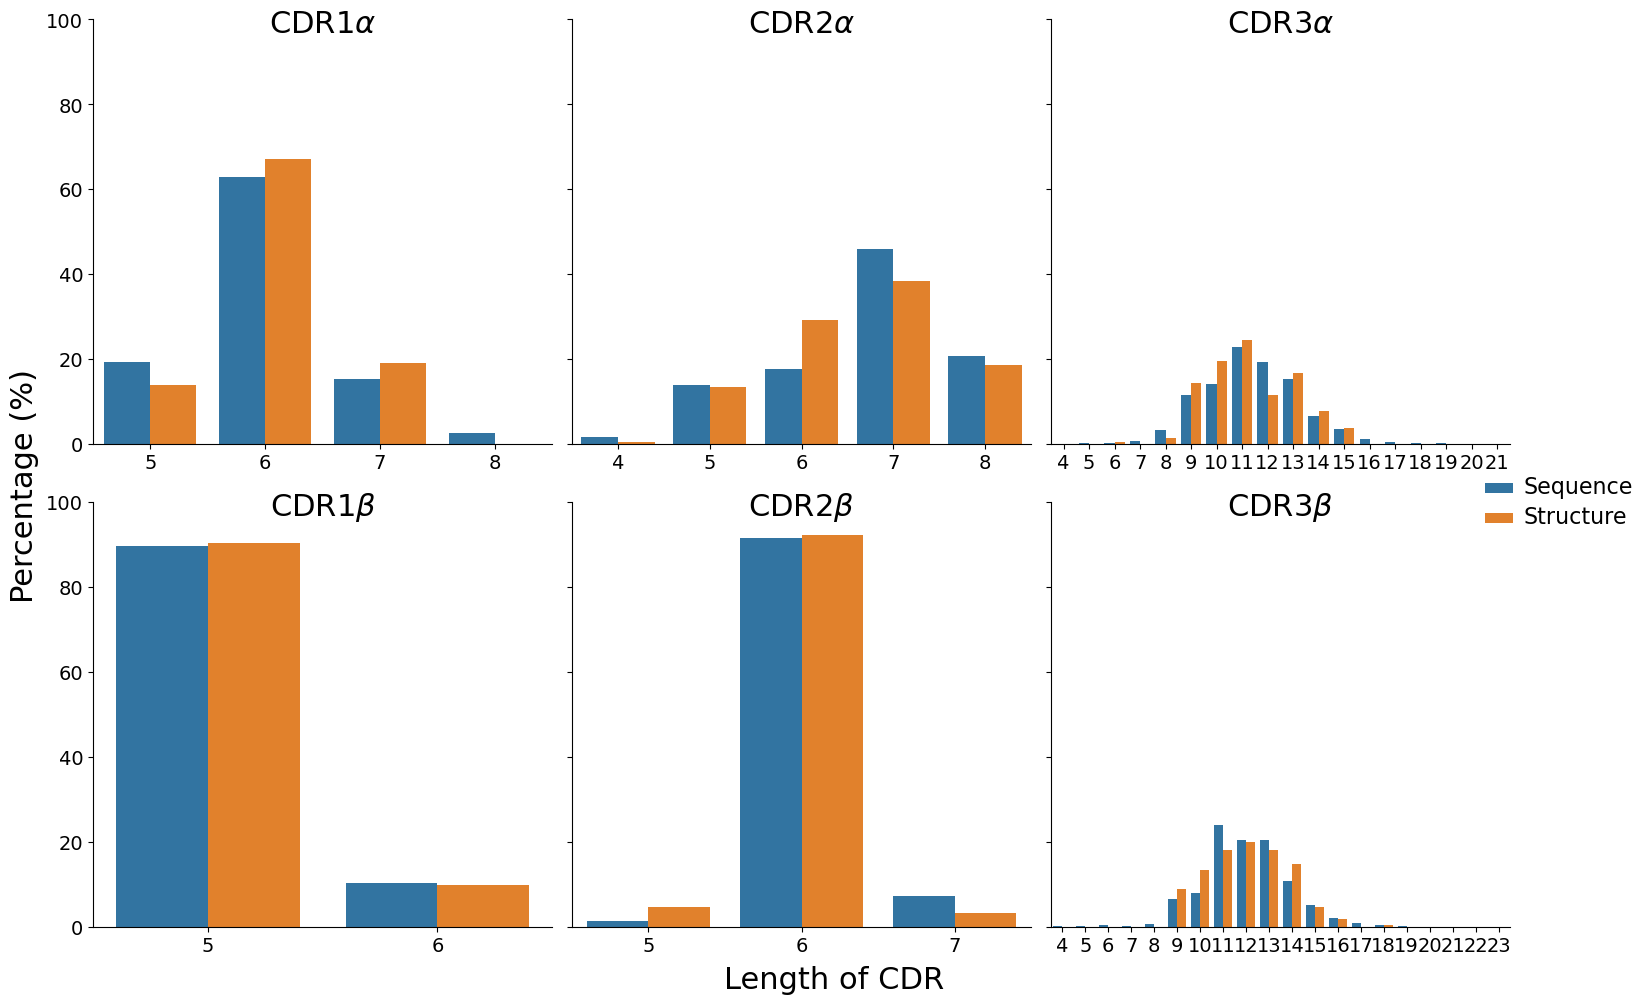

mode       mean       std
chain_type cdr_num type                                
alpha      1       sequence      6   6.010887  0.669532
                   structure     6   6.050926  0.572387
           2       sequence      7   6.698109  1.002844
                   structure     7   6.611111  0.953167
           3       sequence     11  11.418851  1.919230
                   structure    11  11.287037  1.739024
beta       1       sequence      5   5.103352  0.304429
                   structure     5   5.097222  0.296948
           2       sequence      6   6.058874  0.284701
                   structure     6   5.986111  0.280849
           3       sequence     11  12.063458  1.855996
                   structure    12  12.004630  1.782336

In [21]:
grid = sns.catplot(
    cdr_lengths_percentages,
    x='length',
    y='percentage',
    row='chain_type',
    col='cdr_num',
    hue='type',
    kind='bar',
    sharex=False,
)

grid.set(ylim=(0, 100))

titles = {
    (chain_type, cdr_num): f'CDR{cdr_num}$\\{chain_type}$'
    for chain_type, cdr_num in cdr_lengths_percentages[['chain_type', 'cdr_num']].apply(tuple, axis='columns').unique()
}
for (chain_type, cdr_num), ax in grid.axes_dict.items():
    ax.tick_params(axis='both', labelsize=14)
    ax.set_title(titles[(chain_type, cdr_num)], fontsize=22, y=0.95)

for ax in grid.axes.flat:
    ax.tick_params(axis='both', labelsize=14)

grid.legend.set_title('')
for label in grid.legend.texts:
    label.set_text(label.get_text().title())
    label.set_fontsize(16)

grid.set_axis_labels('', '')
grid.figure.suptitle('Length of CDR', x=0.5, y=0.02, fontsize=22)
grid.figure.text(-0.01, 0.5, 'Percentage (%)', va='center', fontsize=22, rotation=90)

plt.savefig('report/figures/dataset_comparison_cdr_lengths.svg')
plt.show()

cdr_lengths.groupby(['chain_type', 'cdr_num', 'type'])['length'].agg([pd.Series.mode, 'mean', 'std'])

### Amino acid composition

In [22]:
cdr_amino_acids = tcr_pmhc_data.filter(regex='cdr[1-3]_(alpha|beta)').map(list)
cdr_amino_acids['type'] = tcr_pmhc_data['type']

cdr_amino_acids = cdr_amino_acids.melt(
    id_vars='type',
    value_vars=[col_name for col_name in cdr_amino_acids.columns if col_name.startswith('cdr')],
    var_name='cdr_type',
    value_name='amino_acid',
)
cdr_amino_acids[['cdr_num', 'chain_type']] = (
    cdr_amino_acids['cdr_type'].str.replace('cdr', '').str.split('_').apply(pd.Series)
)
cdr_amino_acids['cdr_num'] = cdr_amino_acids['cdr_num'].apply(int)

cdr_amino_acids = cdr_amino_acids.explode('amino_acid')

In [23]:
cdr_amino_acids_proportions = cdr_amino_acids.groupby(['type', 'chain_type', 'cdr_num'])['amino_acid'].value_counts(
    normalize=True
)

cdr_amino_acids_proportions = cdr_amino_acids_proportions.reset_index()

In [24]:
AMINO_ACIDS = cdr_amino_acids_proportions['amino_acid'].sort_values().unique().tolist()
print(' '.join(AMINO_ACIDS))

A C D E F G H I K L M N P Q R S T V W Y


In [25]:
angles = np.linspace(0, 2 * np.pi, len(AMINO_ACIDS), endpoint=False).tolist()
amino_acid_angles = dict(zip(AMINO_ACIDS, angles, strict=True))

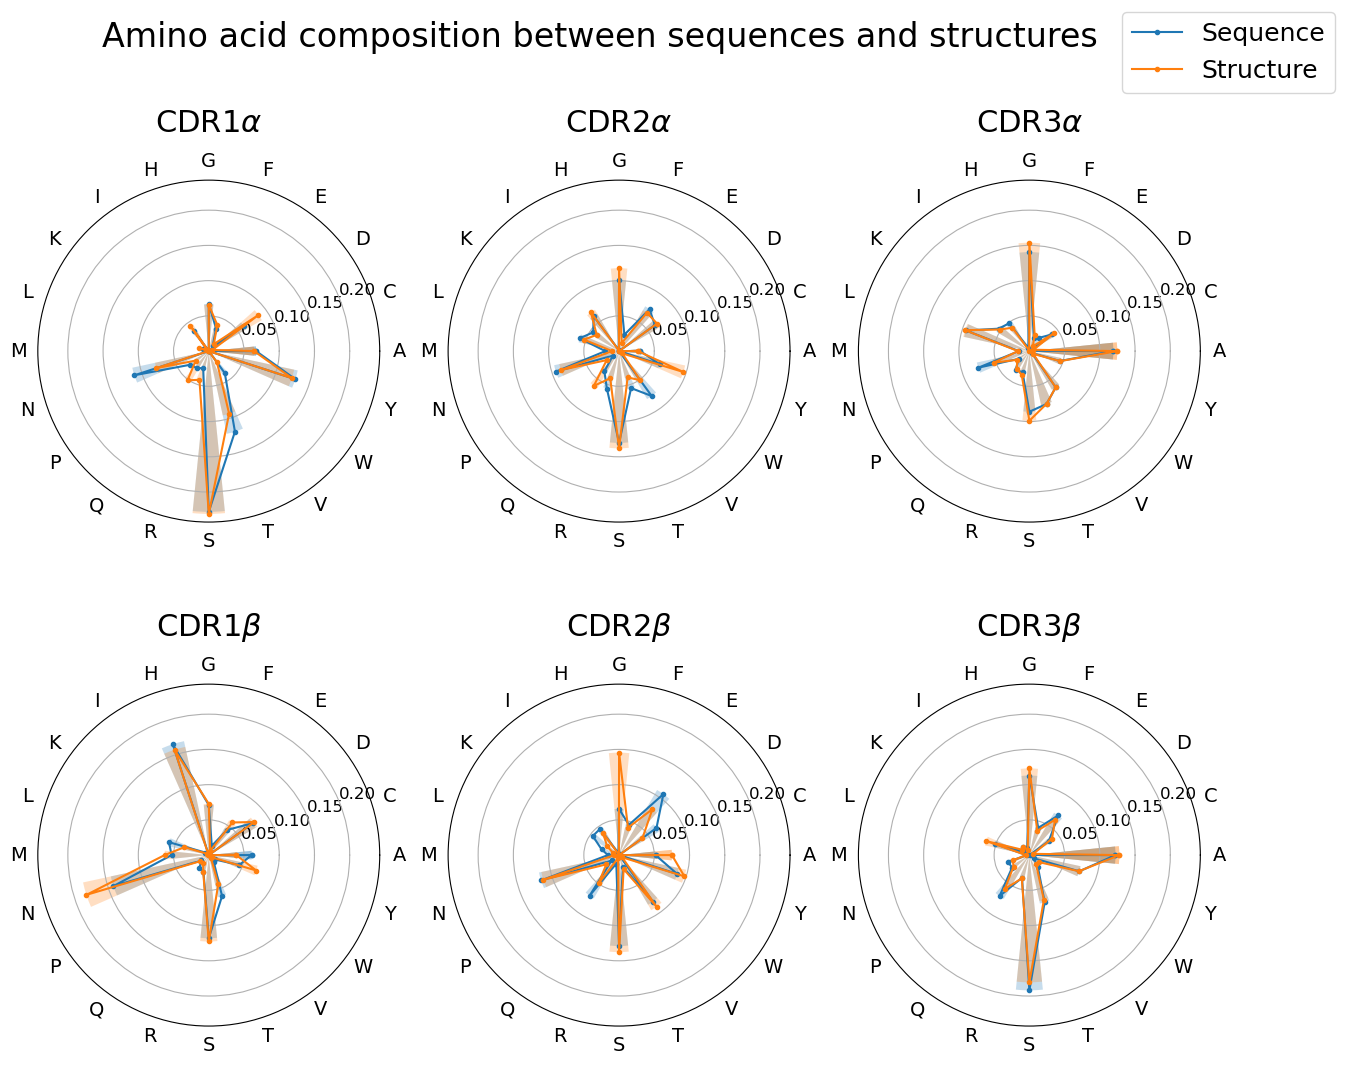

In [26]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 12),
    sharey=True,
    subplot_kw={'projection': 'polar'},
)

lines = []
for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr_num in enumerate((1, 2, 3)):
        for type_ in 'sequence', 'structure':
            selected_proportions = (
                cdr_amino_acids_proportions[
                    (cdr_amino_acids_proportions['type'] == type_)
                    & (cdr_amino_acids_proportions['chain_type'] == chain_type)
                    & (cdr_amino_acids_proportions['cdr_num'] == cdr_num)
                ]
                .sort_values('amino_acid')
                .set_index('amino_acid')['proportion']
            )

            proportions = [selected_proportions.get(amino_acid, 0) for amino_acid in AMINO_ACIDS]
            label_angles = [amino_acid_angles[amino_acid] for amino_acid in AMINO_ACIDS]
            # Join ends
            proportions.append(proportions[0])
            label_angles.append(label_angles[0])

            (line,) = axes[i, j].plot(label_angles, proportions, marker='o', markersize=3, label=type_)
            axes[i, j].bar(label_angles, proportions, alpha=0.25, width=0.2)

            lines.append(line)

        axes[i, j].set_xticks(angles)
        axes[i, j].set_xticklabels(AMINO_ACIDS, fontsize=14)
        axes[i, j].tick_params(axis='y', labelsize=12)
        axes[i, j].grid(which='major', axis='x', visible=False)

        axes[i, j].set_title(f'CDR{cdr_num}$\\{chain_type}$', fontsize=22, pad=35)

unique_handles_labels = {}
for line in lines:
    label = line.get_label().title()
    if label not in unique_handles_labels:
        unique_handles_labels[label] = line

labels, handles = zip(*unique_handles_labels.items(), strict=True)

legend = fig.legend(handles, labels, title='', fontsize=18)

fig.suptitle('Amino acid composition between sequences and structures', fontsize=24)

plt.savefig('report/figures/dataset_comparison_cdr_aa_composition.svg')
plt.show()

## Peptides

### Peptide lengths

In [27]:
peptide_lengths = tcr_pmhc_data[['peptide']].map(len).rename({'peptide': 'length'}, axis='columns')
peptide_lengths['type'] = tcr_pmhc_data['type']


peptide_lengths_percentage = peptide_lengths.groupby('type')['length'].value_counts(normalize=True) * 100
peptide_lengths_percentage.name = 'percentage'
peptide_lengths_percentage = peptide_lengths_percentage.reset_index()

In [28]:
max_length = peptide_lengths_percentage['length'].max()
min_length = peptide_lengths_percentage['length'].min()
expected_lengths = set(range(min_length, max_length + 1))

missing_values = pd.DataFrame()
for type_, group in peptide_lengths_percentage.groupby('type'):
    missing_lengths = expected_lengths - set(group['length'].unique())

    missing_values = pd.concat(
        [
            missing_values,
            pd.DataFrame(
                {
                    'length': list(missing_lengths),
                    'type': [type_ for _ in missing_lengths],
                    'percentage': [0.0 for _ in missing_lengths],
                },
            ),
        ]
    )

peptide_lengths_percentage = pd.concat([peptide_lengths_percentage, missing_values]).reset_index(drop=True)

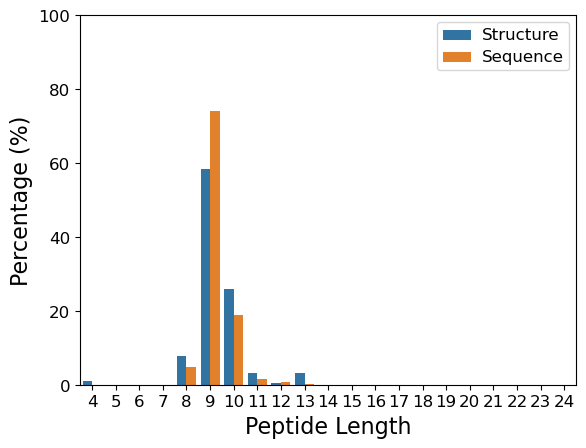

,mode,mean,std
type,,,
sequence,9,9.204340,0.616141
structure,9,9.342593,1.071075


In [29]:
ax = sns.barplot(peptide_lengths_percentage, x='length', y='percentage', hue='type')

ax.set(ylim=(0, 100))
ax.tick_params(axis='both', labelsize=12)

ax.legend_.set_title('')
for label in ax.legend_.texts:
    label.set_text(label.get_text().title())
    label.set_fontsize(12)

plt.xlabel('Peptide Length', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=16)

plt.savefig('report/figures/dataset_comparison_peptide_lengths.svg')
plt.show()

peptide_lengths.groupby('type')['length'].agg([pd.Series.mode, 'mean', 'std'])

### Amino acid composition

In [30]:
peptide_amino_acids = tcr_pmhc_data[['peptide']].map(list).rename({'peptide': 'amino_acid'}, axis='columns')
peptide_amino_acids['type'] = tcr_pmhc_data['type']

peptide_amino_acids = peptide_amino_acids.explode('amino_acid')

In [31]:
peptide_amino_acids_proportions = (
    peptide_amino_acids.groupby('type')['amino_acid'].value_counts(normalize=True).reset_index()
)

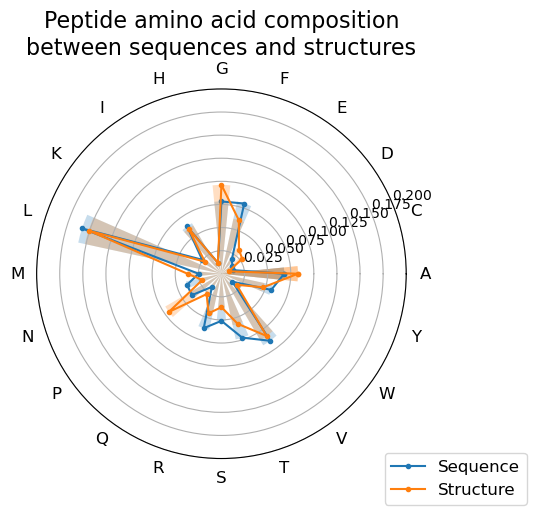

In [32]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

lines = []
for type_ in 'sequence', 'structure':
    selected_proportions = (
        peptide_amino_acids_proportions[peptide_amino_acids_proportions['type'] == type_]
        .sort_values('amino_acid')
        .set_index('amino_acid')['proportion']
    )

    proportions = [selected_proportions.get(amino_acid, 0) for amino_acid in AMINO_ACIDS]
    label_angles = [amino_acid_angles[amino_acid] for amino_acid in AMINO_ACIDS]

    # Join ends
    proportions.append(proportions[0])
    label_angles.append(label_angles[0])

    (line,) = ax.plot(label_angles, proportions, marker='o', markersize=3, label=type_)
    ax.bar(label_angles, proportions, alpha=0.25, width=0.2)

    lines.append(line)

ax.set_ylim(0, 0.2)
ax.set_xticks(angles)
ax.set_xticklabels(AMINO_ACIDS, fontsize=12)
ax.tick_params(axis='y', labelsize=10)
ax.grid(which='major', axis='x', visible=False)

unique_handles_labels = {}
for line in lines:
    label = line.get_label().title()
    if label not in unique_handles_labels:
        unique_handles_labels[label] = line

labels, handles = zip(*unique_handles_labels.items(), strict=True)

legend = fig.legend(handles, labels, title='', fontsize=12, loc='lower right')

plt.title('Peptide amino acid composition\nbetween sequences and structures', fontsize=16, pad=25)

plt.savefig('report/figures/dataset_comparison_peptide_aa_composition.svg')
plt.show()

### Peptide Clustering

In [33]:
peptide_sequences = tcr_pmhc_data[['peptide', 'type']].drop_duplicates()

In [34]:
peptide_sequences = (
    peptide_sequences.groupby('peptide')['type']
    .agg(lambda types: 'both' if len(types) > 1 else types.iloc[0])
    .reset_index()
)

In [35]:
distance_matrix = np.zeros((peptide_sequences['peptide'].shape[0], peptide_sequences['peptide'].shape[0]), dtype=int)

for i in range(peptide_sequences['peptide'].shape[0]):
    for j in range(i + 1, peptide_sequences['peptide'].shape[0]):
        distance_matrix[i, j] = damerau_levenshtein_distance(
            peptide_sequences['peptide'].iloc[i],
            peptide_sequences['peptide'].iloc[j],
        )

distance_matrix = np.maximum(distance_matrix, distance_matrix.T)

print(
    f'The average levenshtein distance between all peptide sequences is {np.average(distance_matrix):.2f} edits',
    f'with an standard deviation of {np.std(distance_matrix):.2f} edits.',
)

The average levenshtein distance between all peptide sequences is 8.43 edits with an standard deviation of 1.31 edits.


In [36]:
CUTOFF_PERCENT = 70

sequence_lengths = peptide_sequences['peptide'].str.len()
grid1, grid2 = np.meshgrid(sequence_lengths, sequence_lengths)

max_lengths = np.maximum(grid1, grid2)
sequence_percent_identities = ((max_lengths - distance_matrix) / max_lengths) * 100

similar_peptides = sequence_percent_identities > CUTOFF_PERCENT

In [37]:
G = nx.Graph()
G.add_nodes_from(range(peptide_sequences['peptide'].shape[0]))

for i in range(1, len(peptide_sequences)):
    for j in range(i + 1, len(peptide_sequences)):
        if similar_peptides[i, j]:
            G.add_edge(i, j, weight=sequence_percent_identities[i, j] / 100)

In [38]:
colours = peptide_sequences['type'].map({'sequence': 'tab:blue', 'structure': 'tab:orange', 'both': 'tab:green'})

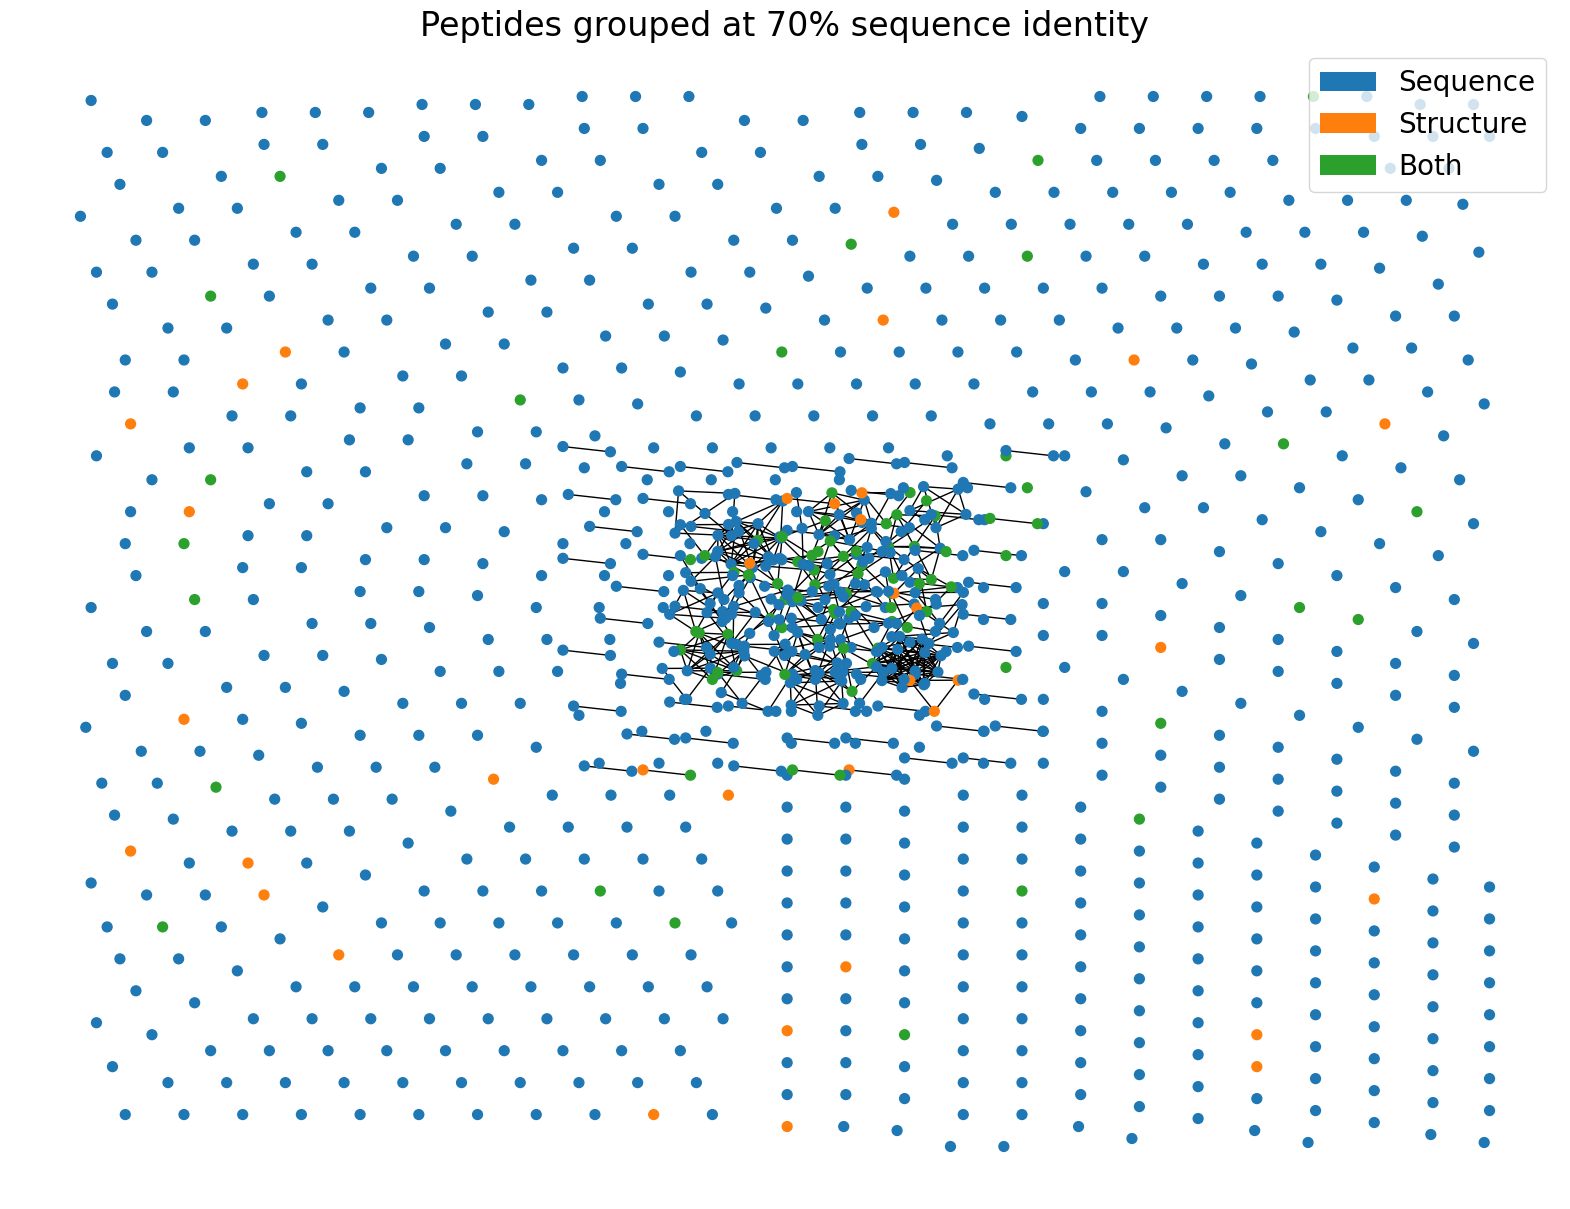

In [39]:
plt.figure(figsize=(20, 15))
plt.title('Peptides grouped at 70% sequence identity', fontsize=24)

nx.draw(
    G,
    node_size=50,
    node_color=colours.tolist(),
    pos=nx.drawing.nx_agraph.graphviz_layout(G, prog='neato'),
)

legend_elements = [
    Patch(facecolor='tab:blue', label='Sequence'),
    Patch(facecolor='tab:orange', label='Structure'),
    Patch(facecolor='tab:green', label='Both'),
]

plt.legend(handles=legend_elements, loc='upper right', fontsize=20)

plt.savefig('report/figures/dataset_comparison_peptide_clustering.svg')
plt.show()

## MHCs

### Alleles

In [40]:
mhc_alleles = tcr_pmhc_data[['mhc1', 'mhc2', 'type']].copy()

In [41]:
mhc_alleles['mhc1'] = mhc_alleles['mhc1'].fillna('Unknown')

In [42]:
mhc_alleles['mhc1'] = mhc_alleles['mhc1'].str.split(';')
mhc_alleles = mhc_alleles.explode('mhc1')

In [43]:
mhc_alleles['mhc1'] = mhc_alleles['mhc1'].map(
    lambda gene: {
        'MH2-D1': 'H2-D1',
        'H2-Db': 'H2-D1',
        'H2-Dd': 'H2-D1',
    }.get(gene, gene)
)

In [44]:
mhc1_allele_proportions = (
    mhc_alleles.groupby('type')['mhc1']
    .value_counts(normalize=True)
    .reset_index()
    .rename({'mhc1': 'Allele'}, axis='columns')
    .pivot_table(index='Allele', values='proportion', columns='type')
    .fillna(0)
)
mhc1_allele_proportions.sort_index()

mhc1_allele_proportions['change'] = mhc1_allele_proportions['structure'] - mhc1_allele_proportions['sequence']

In [45]:
mhc1_allele_proportions = mhc1_allele_proportions.loc[
    [idx for idx in mhc1_allele_proportions.index if idx != 'Unknown']
]

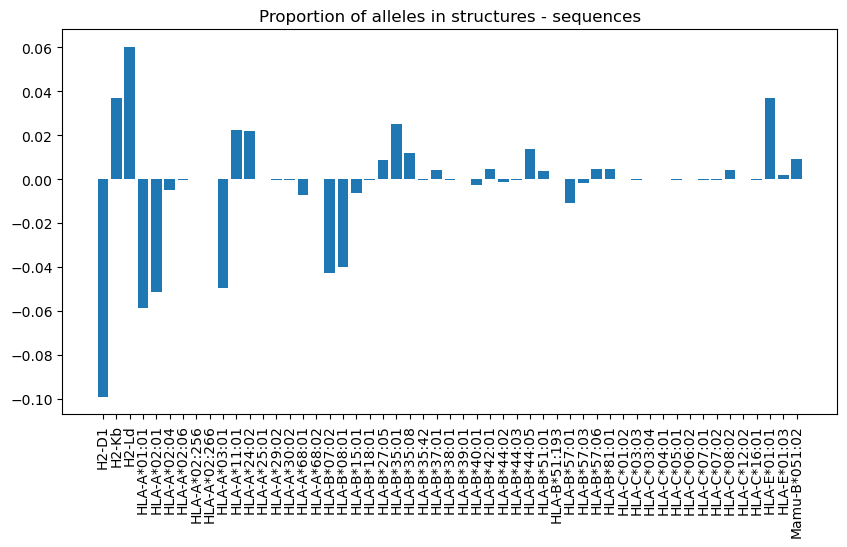

In [46]:
plt.figure(figsize=(10, 5))

plt.bar(mhc1_allele_proportions.index, mhc1_allele_proportions['change'])

plt.xticks(rotation=90)

plt.title('Proportion of alleles in structures - sequences')

plt.savefig('report/figures/dataset_comparison_mhc_genes.svg')
plt.show()

### Pseudo sequences

In [47]:
mhc_pseudo_sequences = tcr_pmhc_data[['mhc_pseudo', 'type']].copy()

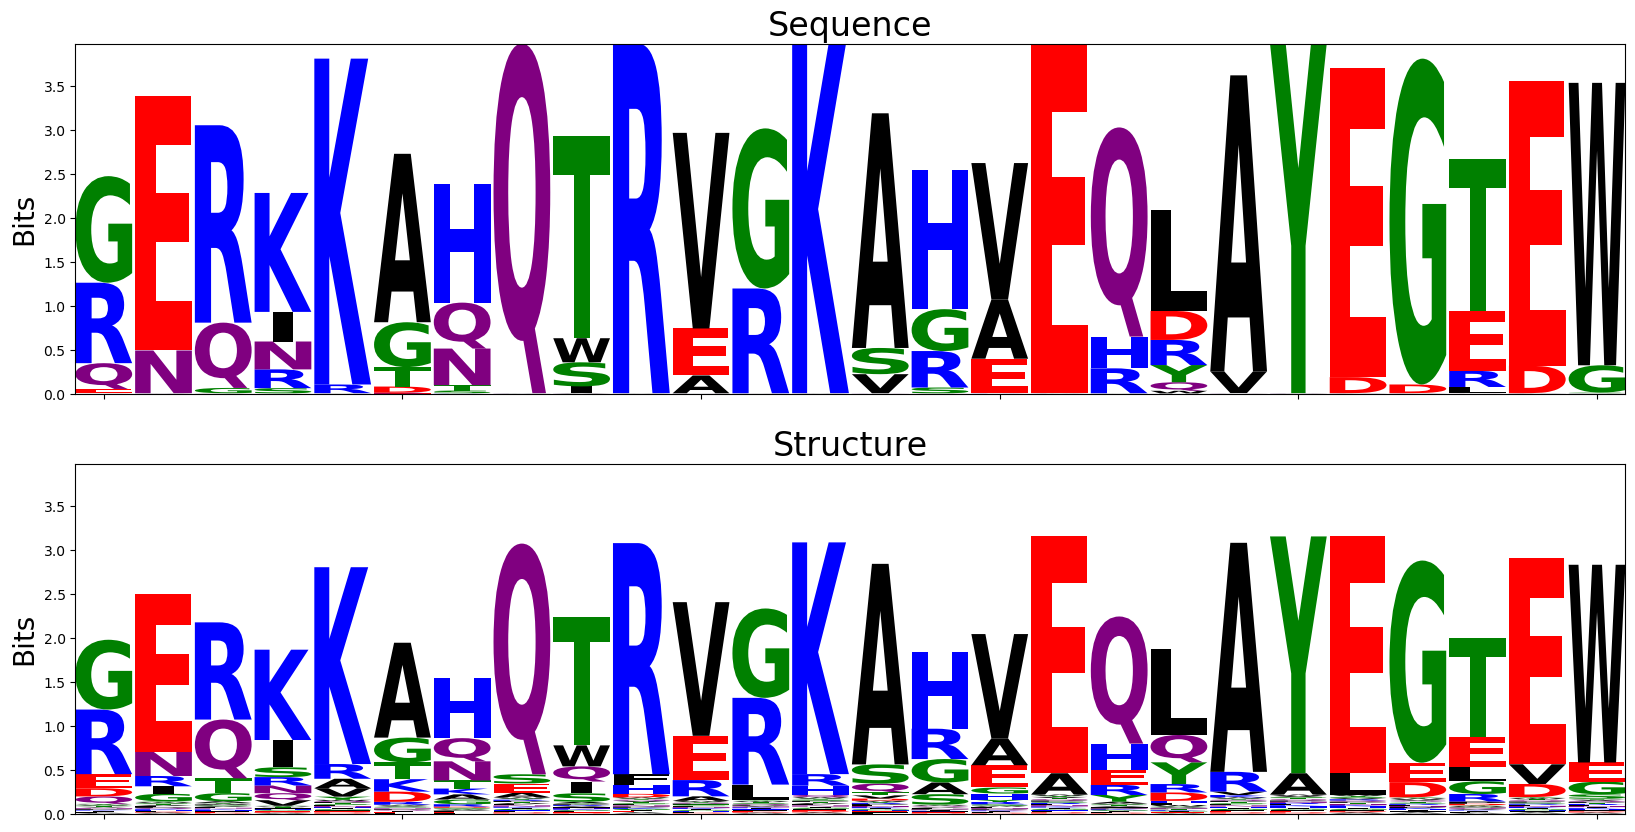

In [48]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(20, 10))

probs = {
    type_: logomaker.alignment_to_matrix(group['mhc_pseudo'], to_type='information')
    for type_, group in mhc_pseudo_sequences.groupby('type')
}

y_max = max([prob.sum(axis='columns').max() for prob in probs.values()])

columns = sorted({col_name for prob in probs.values() for col_name in prob.columns})

for prob in probs.values():
    for col_name in columns:
        if col_name not in prob.columns:
            prob[col_name] = 0.0

logomaker.Logo(probs['sequence'], color_scheme='chemistry', ax=ax1)
ax1.set_title('Sequence', fontsize=24)
ax1.set_ylabel('Bits', fontsize=20)
ax1.set_xticklabels([])
ax1.set_ylim([0, y_max])

logomaker.Logo(probs['structure'], color_scheme='chemistry', ax=ax2)
ax2.set_title('Structure', fontsize=24)
ax2.set_ylabel('Bits', fontsize=20)
ax2.set_xticklabels([])
ax2.set_ylim([0, y_max])

plt.show()

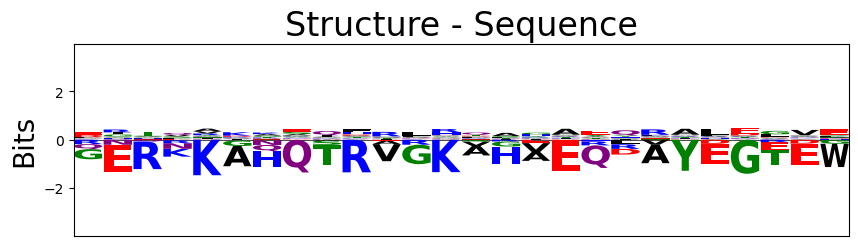

In [49]:
logomaker.Logo(probs['structure'] - probs['sequence'], color_scheme='chemistry', flip_below=False)

plt.title('Structure - Sequence', fontsize=24)
plt.ylabel('Bits', fontsize=20)
plt.xticks([])
plt.ylim((-y_max, y_max))

plt.savefig('report/figures/dataset_comparison_mhc_pseudo_sequences.svg')
plt.show()